# Baseline Steel Thread — Isolating the Effect of Interventions on Item Warm-Up

This notebook builds a controlled experiment for measuring how a recommender's ability to
retrieve an item changes as that item accumulates its own interaction history — and it's
built specifically so that later interventions (content embeddings, improved content
embeddings, LLM-simulated interactions) can be added and compared on equal footing.

**The core experimental principle:** hold every source of variation fixed except the one
under study. User preferences are fit once, frozen, and reused identically everywhere in
this notebook — for the baseline pure-CF method here, and for every future method this
experiment gets extended to. Only the *item's* representation is allowed to change as it
gains interaction history. This means an observed change in retrieval quality can be
attributed to "this item gained more signal," not to "the model also happened to relearn
different user preferences this time."

**Dataset:** MovieLens 100k (proof-of-concept).

**Runtime:** Apple Silicon (M5, 48 GB unified memory). `implicit` runs CPU-only on Mac.

**Kernel:** select **`Python (699-baseline-steel-thread)`** (top-right kernel picker).

---
## Module layout

The pipeline logic itself now lives in four importable modules, not in this notebook:

- **`load.py`** — fetch/load MovieLens, ID remapping, the cold/warm split, and the warm-item
  reference train/test split. Returns one `Dataset` object.
- **`protocol.py`** — `RetrievalModel`, the structural contract (`fit`/`recommend`/
  `score_matrix`/`fold_in`) every retrieval method below satisfies, so `eval.py` never
  branches on model type.
- **`pop.py`** — `PopularityModel` (Section 5a) and `ActivityModel`, its Mode-B dual.
- **`cf.py`** — `ALSModel` (Section 5b), wrapping `implicit`'s ALS.
- **`eval.py`** — every metric function, the warm-item reference score, and both warm-up
  sweeps (Mode A: user-centric; Mode B: item-to-user). One `sweep()`/`sweep_item_to_user()`
  call replaces what used to be a separate hand-written loop per model.

A future intervention (a content-based hybrid method, say) becomes a new module implementing
`RetrievalModel` — plugging into `eval.py` with no changes to `eval.py` itself.

### Note on the `implicit` API
This notebook targets **`implicit` 0.7.x**. `model.fit()`, `ndcg_at_k()`, and
`model.recommend()` all expect a **user × item** matrix; we build and use one consistently
throughout. `AlternatingLeastSquares.recalculate_item(itemid, item_users)` is the one
exception — it expects **item × user** orientation. This is handled once, inside
`Dataset.revealed_item_users_at_k()` and `cf.ALSModel.fold_in()`, rather than at every call
site as before.

## 0. Environment & imports

In [1]:
import platform
import sys

sys.path.insert(0, "..")  # notebook lives in notebooks/; the recsys/ package is one level up

import numpy as np
import matplotlib.pyplot as plt
import implicit

from recsys import load
from recsys import pop
from recsys import cf
from recsys import eval as ev

print(f"python     {platform.python_version()}  ({platform.machine()})")
print(f"implicit   {implicit.__version__}")

python     3.12.13  (arm64)
implicit   0.7.3


## 1-4. Load MovieLens, build the cold/warm split

See `load.py` for the full mechanism (ID remapping, sparse matrix construction, the cold-item
eligibility filter and reveal/reserve split, and the warm-item reference split). Briefly:

- A fixed 10% of items with at least 25 total interactions are selected as structurally
  "cold" (`load.load_dataset`'s defaults: `min_interactions=25`, `cold_item_fraction=0.10`).
- Each cold item's first 20 interactions (chronologically) form its revealable history —
  `Dataset.revealed_matrix_at_k(k)`/`revealed_item_users_at_k(k)` expose exactly the first
  `k` of these; everything after is permanently reserved for evaluation (`Dataset.test_matrix`).
- A separate random 80/20 split on the warm (non-cold) items gives `Dataset.ref_train`/
  `ref_test` — every model in this notebook fits on `ref_train`, so no model has ever seen a
  single cold-item interaction.

In [2]:
dataset = load.load_dataset(data_dir="../data/ml-100k")
N_REVEAL = 20
K_LEVELS = list(range(N_REVEAL + 1))  # 0, 1, 2, ..., 20

print(f"users: {dataset.n_users:,}   items: {dataset.n_items:,}")
print(f"cold items: {len(dataset.cold_item_ids)}")
print(f"ref_train non-zeros: {dataset.ref_train.nnz:,}   ref_test non-zeros: {dataset.ref_test.nnz:,}")
print(f"reserved cold-item test interactions: {dataset.test_matrix.nnz:,}")

users: 943   items: 1,682
cold items: 87
ref_train non-zeros: 72,833   ref_test non-zeros: 18,055
reserved cold-item test interactions: 7,372


## 5. Two retrieval models — popularity baseline and collaborative filtering

This is the point in the pipeline where different retrieval **methods** are compared, side
by side, against the exact same data — 5a is a no-collaborative-filtering floor, 5b is the
collaborative-filtering method under study today. A future intervention becomes a third
`RetrievalModel` implementation here, not a restructuring of this notebook.

**Both models fit on `dataset.ref_train`** — nothing else, and this matters. It contains only
warm items, so the resulting user representations have never seen a single cold item's
interaction, at any point.

### 5a. Popularity baseline (no collaborative filtering)

Ranks items by raw training-interaction count — the same global list for every user,
personalized only by excluding each user's already-seen items. See `pop.PopularityModel`.

In [3]:
pop_model = pop.PopularityModel().fit(dataset.ref_train)
print(f"Most popular item (train_index {pop_model.ranked_items[0]}): "
      f"{pop_model.popularity[pop_model.ranked_items[0]]} training interactions")

Most popular item (train_index 49): 482 training interactions


### 5b. Collaborative filtering — ALS

`implicit.als.AlternatingLeastSquares`, wrapped by `cf.ALSModel` to satisfy
`protocol.RetrievalModel`. `factors`/`iterations` are intentionally small here for fast
iteration — on 48 GB of unified memory both can be pushed much higher later without memory
pressure.

In [4]:
ALS_PARAMS = dict(factors=50, regularization=0.01, iterations=15)

model = cf.ALSModel(random_state=42, **ALS_PARAMS)
print("Fitting ALS on the reference training set...")
model.fit(dataset.ref_train)
print("Done.")

Fitting ALS on the reference training set...
Done.


## 6. Warm-item reference score

Computed **ahead of** Section 7's cold-start evaluation, on purpose: reading that result with
no frame of reference tells you little on its own. Both models are evaluated on
`dataset.ref_test` using each model's own natively-fit representations — no fold-in involved,
that mechanism is specific to the cold-item sweep below.

**Why `N_SEEDS` independent fits.** ALS's factor initialization is random, so a single fit is
one sample from a distribution of outcomes. Refitting `N_SEEDS` times and reporting mean ±
spread gives an honest picture of signal vs. initialization noise. These same fits are reused,
unchanged, for Section 9's warm-up curve.

**Metrics:** NDCG@K (ranked-list quality vs. the best possible ordering), Precision@K, Recall@K,
and HitRate@K (macro-averaged coverage), and AUC (full-catalog pairwise ranking probability, no
K involved). **Why K=100:** this is a retrieval-stage evaluation — is the item surfaced into a
broad candidate pool at all, not whether it lands in a top-10 a user would literally see. A
strict top-10 cutoff turns out to make no distinction at all in this experiment (a cold item
competing against ~1,600 fully-trained warm items for 1 of 10 slots never wins, for any user,
at any reveal level) — at K=100 a real, growing signal is visible instead.

In [5]:
K = 100
N_SEEDS = 10
METRICS = ev.METRICS  # ["NDCG", "Precision", "Recall", "HitRate", "AUC"]

seed_models = [cf.ALSModel(random_state=seed, **ALS_PARAMS).fit(dataset.ref_train) for seed in range(N_SEEDS)]
print(f"Fit {N_SEEDS} independent ALS models on the reference training set (seeds 0-{N_SEEDS - 1}).")

pop_ref = ev.reference_scores([pop_model], dataset, K=K)
als_ref = ev.reference_scores(seed_models, dataset, K=K)

print(f"\nWarm-item reference — random 80/20 split ({dataset.ref_train.nnz:,} train / "
      f"{dataset.ref_test.nnz:,} test, {pop_ref['n_eval']:,} eval users):")
for m in METRICS:
    label = m if m == "AUC" else f"{m}@{K}"
    print(f"  {label}: Popularity={pop_ref['mean'][m]:.4f}   "
          f"ALS={als_ref['mean'][m]:.4f} ± {als_ref['std'][m]:.4f}")

Fit 10 independent ALS models on the reference training set (seeds 0-9).



Warm-item reference — random 80/20 split (72,833 train / 18,055 test, 943 eval users):
  NDCG@100: Popularity=0.2975   ALS=0.4635 ± 0.0018
  Precision@100: Popularity=0.0832   ALS=0.1070 ± 0.0004
  Recall@100: Popularity=0.4503   ALS=0.6524 ± 0.0021
  HitRate@100: Popularity=0.9576   ALS=0.9897 ± 0.0013
  AUC: Popularity=0.8717   ALS=0.8840 ± 0.0010


## 7. Cold-start evaluation

Every reserved test interaction belongs to a cold item, evaluated at reveal level `k=0` — no
history revealed at all. For ALS this has an exact, provable answer: `recalculate_item`'s
closed-form solve at k=0 has nothing but regularization to fall back on, so the fold-in factor
is the exact zero vector, verified computationally below. Popularity's k=0 failure is simpler:
a cold item has a training interaction count of exactly zero, so it can never appear in a
"most popular" ordering, regardless of training dynamics.

Compare against Section 6's reference score above for what "normal" looks like on this system.

In [6]:
folded_k0 = seed_models[0].fold_in(dataset, k=0)
max_abs_factor = np.abs(folded_k0.item_factors[dataset.cold_item_ids]).max()
print(f"max |factor| at k=0 across all cold items, seed 0: {max_abs_factor:.10f} (expect exactly 0)")

pop_k0 = ev.evaluate_at_k(pop_model, dataset, k=0, K=K)
als_k0 = [ev.evaluate_at_k(m, dataset, k=0, K=K) for m in seed_models]
als_k0_mean = {m: float(np.mean([r[m] for r in als_k0])) for m in METRICS}
als_k0_std = {m: float(np.std([r[m] for r in als_k0])) for m in METRICS}

print(f"\nCold-start (k=0), evaluated over {pop_k0['n_eval']:,} users with a held-out cold-item interaction:")
for m in METRICS:
    label = m if m == "AUC" else f"{m}@{K}"
    print(f"  {label}: Popularity={pop_k0[m]:.4f}   ALS={als_k0_mean[m]:.4f} ± {als_k0_std[m]:.4f}")

max |factor| at k=0 across all cold items, seed 0: 0.0000000000 (expect exactly 0)



Cold-start (k=0), evaluated over 860 users with a held-out cold-item interaction:
  NDCG@100: Popularity=0.0000   ALS=0.0000 ± 0.0000
  Precision@100: Popularity=0.0000   ALS=0.0000 ± 0.0000
  Recall@100: Popularity=0.0000   ALS=0.0000 ± 0.0000
  HitRate@100: Popularity=0.0000   ALS=0.0000 ± 0.0000
  AUC: Popularity=0.0328   ALS=0.4213 ± 0.0009


## 8. Example — top-5 recommendations for one user, both models

Popularity's list is identical for every user (minus their own already-seen items) — no
personalization signal at all, just a global ranking. ALS's list is user-specific.

In [7]:
titles = load.load_titles(data_dir="../data/ml-100k")
sample_user_index = 0
raw_user_id = dataset.index_to_user[sample_user_index]

for name, m in [("Popularity", pop_model), ("ALS", model)]:
    recs = ev.top_n_recommendations(m, dataset, sample_user_index, N=5, titles=titles)
    print(f"--- {name}: top 5 for user_index {sample_user_index} (raw user_id {raw_user_id}) ---")
    for r in recs:
        print(f"  item_index {r['item_index']:>4} | raw_id {r['raw_item_id']:>4} | "
              f"score {r['score']:>8.4f} | {r['title']}")
    print()

--- Popularity: top 5 for user_index 0 (raw user_id 1) ---
  item_index  285 | raw_id  286 | score 400.0000 | English Patient, The (1996)
  item_index  287 | raw_id  288 | score 385.0000 | Scream (1996)
  item_index  293 | raw_id  294 | score 368.0000 | Liar Liar (1997)
  item_index  299 | raw_id  300 | score 344.0000 | Air Force One (1997)
  item_index  126 | raw_id  127 | score 329.0000 | Godfather, The (1972)

--- ALS: top 5 for user_index 0 (raw user_id 1) ---
  item_index  195 | raw_id  196 | score   0.9505 | Dead Poets Society (1989)
  item_index  287 | raw_id  288 | score   0.8164 | Scream (1996)
  item_index  473 | raw_id  474 | score   0.7856 | Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1963)
  item_index  155 | raw_id  156 | score   0.7654 | Reservoir Dogs (1992)
  item_index  194 | raw_id  195 | score   0.6849 | Terminator, The (1984)



## 9. Warm-up curve

For each reveal level `k` from 0 to 20, folds every cold item in using exactly the first `k`
of its own revealed interactions, evaluates against the same fixed reserved test set, and
repeats across the `N_SEEDS` models fit in Section 6. `eval.sweep()` replaces what used to be
a hand-written per-model loop with one call per method.

In [8]:
pop_curve, _ = ev.sweep([pop_model], dataset, K_LEVELS, K=K)
als_curve, n_eval_per_k = ev.sweep(seed_models, dataset, K_LEVELS, K=K)

print("Warm-up sweep:")
for i, k in enumerate(K_LEVELS):
    print(f"k={k:>2}  eval users={n_eval_per_k[i]:>4}  "
          + "  ".join(f"{m}: Pop={pop_curve[m]['mean'][i]:.4f} ALS={als_curve[m]['mean'][i]:.4f}" for m in METRICS))

print(f"\nPopularity is exact (deterministic) throughout. ALS is the mean of {N_SEEDS} independent fits — "
      f"the shaded band on each plot below is that spread.")

Warm-up sweep:
k= 0  eval users= 860  NDCG: Pop=0.0000 ALS=0.0000  Precision: Pop=0.0000 ALS=0.0000  Recall: Pop=0.0000 ALS=0.0000  HitRate: Pop=0.0000 ALS=0.0000  AUC: Pop=0.0328 ALS=0.4213
k= 1  eval users= 860  NDCG: Pop=0.0000 ALS=0.0000  Precision: Pop=0.0000 ALS=0.0000  Recall: Pop=0.0000 ALS=0.0000  HitRate: Pop=0.0000 ALS=0.0000  AUC: Pop=0.0859 ALS=0.4402
k= 2  eval users= 860  NDCG: Pop=0.0000 ALS=0.0000  Precision: Pop=0.0000 ALS=0.0000  Recall: Pop=0.0000 ALS=0.0000  HitRate: Pop=0.0000 ALS=0.0000  AUC: Pop=0.1560 ALS=0.4550
k= 3  eval users= 860  NDCG: Pop=0.0000 ALS=0.0000  Precision: Pop=0.0000 ALS=0.0000  Recall: Pop=0.0000 ALS=0.0000  HitRate: Pop=0.0000 ALS=0.0000  AUC: Pop=0.2056 ALS=0.4696
k= 4  eval users= 860  NDCG: Pop=0.0000 ALS=0.0000  Precision: Pop=0.0000 ALS=0.0000  Recall: Pop=0.0000 ALS=0.0000  HitRate: Pop=0.0000 ALS=0.0001  AUC: Pop=0.2498 ALS=0.4919
k= 5  eval users= 860  NDCG: Pop=0.0000 ALS=0.0000  Precision: Pop=0.0000 ALS=0.0000  Recall: Pop=0.0000 

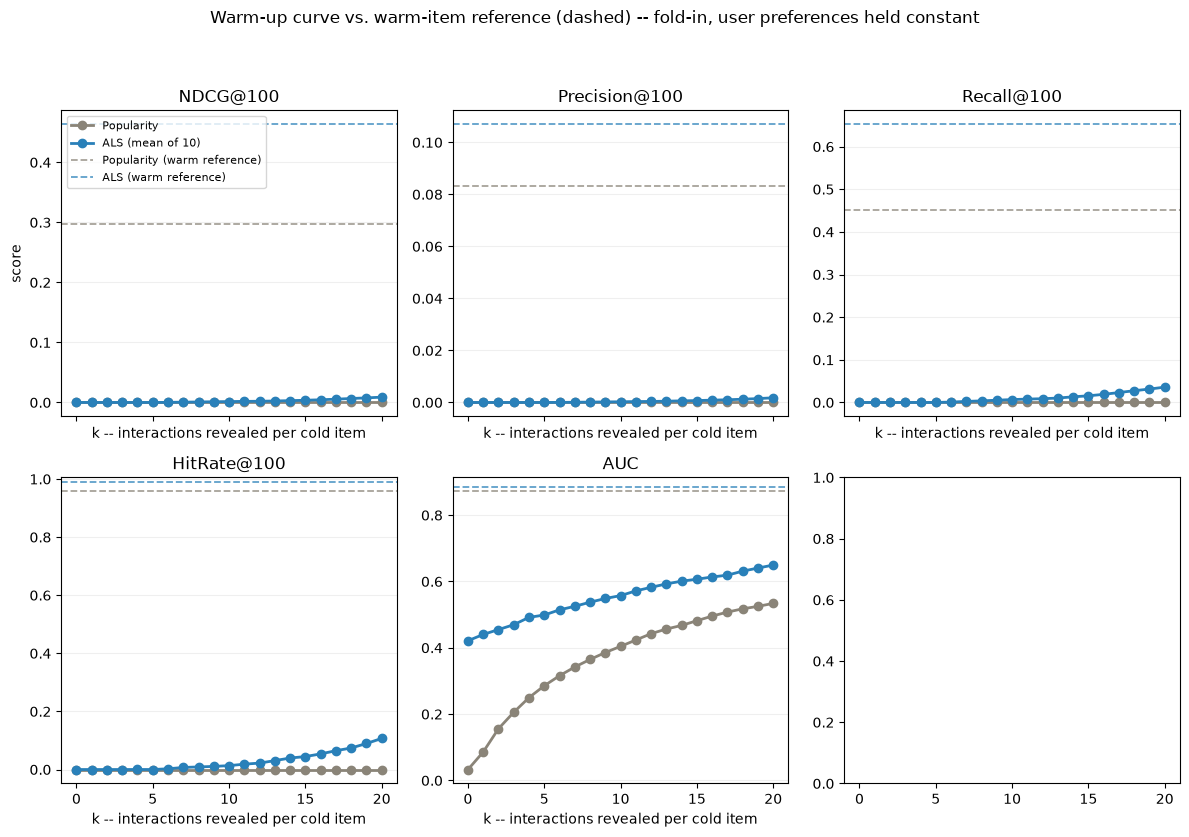

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8), sharex='col')
axes = axes.flatten()

for i, (ax, metric) in enumerate(zip(axes, METRICS)):
    als_mean = np.array(als_curve[metric]["mean"])
    als_std = np.array(als_curve[metric]["std"])
    show_label = (lambda text: text) if i == 0 else (lambda text: None)

    ax.plot(K_LEVELS, pop_curve[metric]["mean"], marker="o", markersize=6, linewidth=2,
            color="#8A8478", label=show_label("Popularity"))
    ax.plot(K_LEVELS, als_mean, marker="o", markersize=6, linewidth=2,
            color="#2980b9", label=show_label(f"ALS (mean of {N_SEEDS})"))
    ax.fill_between(K_LEVELS, als_mean - als_std, als_mean + als_std, color="#2980b9", alpha=0.15, linewidth=0)
    ax.axhline(pop_ref["mean"][metric], color="#8A8478", linestyle="--", linewidth=1.3, alpha=0.75,
               label=show_label("Popularity (warm reference)"))
    ax.axhline(als_ref["mean"][metric], color="#2980b9", linestyle="--", linewidth=1.3, alpha=0.75,
               label=show_label("ALS (warm reference)"))

    ax.set_title("AUC" if metric == "AUC" else f"{metric}@{K}")
    ax.set_xlabel("k -- interactions revealed per cold item")
    ax.grid(axis="y", alpha=0.2)

axes[0].set_ylabel("score")
axes[0].legend(fontsize=8, loc="upper left")
fig.suptitle("Warm-up curve vs. warm-item reference (dashed) -- fold-in, user preferences held constant", y=1.04)
plt.tight_layout()
plt.show()

## 10. Warm-up curve — item-to-user view (Mode B)

Section 9 asks, from a *user's* perspective: does this cold item surface in my personal
top-K? This asks the same question from the opposite direction — for a single cold item, rank
every user by predicted affinity, and check whether the users known (from the reserved test
set) to actually be interested in it land near the top of *its* top-K. Same fold-in factors as
Section 7/9, just a transposed ranking axis — see `eval.evaluate_item_to_user_at_k`.

**Why Popularity has no line here, and Activity does.** Popularity assigns every user an
identical score for a given item — no per-user signal to rank users *by*. But the *principle*
behind it — rank by observed volume, no personalization — has a direct dual on this axis:
**global user activity** (`pop.ActivityModel`), ranking users by their total interaction count
in `ref_train`, frozen exactly like `user_factors` are treated everywhere else.

**Why `K=10` here, not Section 9's `K=100`.** Mode B's candidate pool is the ~940 remaining
users, not the ~1,600-item catalog. At `K=100`, even a weak ranking clears a near-guaranteed
hit against the ~85-user average reserved test set, so HitRate@100 saturates near 1.0 and
stops discriminating between models.

**Downsampled Test Set.** Recall@K is capped at `K/r_i` and Precision@K at `r_i/K` for an item
with `r_i` reserved test users — real cross-item comparability problems when `r_i` ranges from
5 to 487 across these 87 items. The fix (`eval.build_mode_b_context`): draw a fixed, random
5-user sample from each cold item's reserved test pool for NDCG/Precision/Recall/HitRate. Every
eligible item is guaranteed at least 5 reserved users by construction
(`MIN_INTERACTIONS(25) - N_REVEAL(20) = 5`). AUC stays on the full reserved test set throughout.

**`eval.mode_b_ceiling`** reports what a hypothetically perfect ranking would score on each
metric — NDCG/HitRate/AUC are trivially 1.0; Precision@K and Recall@K actually depend on `r_i`
and are the two worth reading against their ceiling.

In [10]:
DOWNSAMPLE_SIZE = 5
K_MODE_B = 10
METRICS_MODE_B = ev.METRICS_MODE_B  # ["NDCG", "Precision", "Recall", "HitRate", "AUC"]

mode_b_ctx = ev.build_mode_b_context(dataset, downsample_size=DOWNSAMPLE_SIZE, seed=42)
activity_model = pop.ActivityModel().fit(dataset.ref_train)

print(f"Downsampled test set: {mode_b_ctx.downsampled_test_matrix.nnz:,} interactions across "
      f"{len(dataset.cold_item_ids)} items ({DOWNSAMPLE_SIZE} per item, exactly).")

ceiling = ev.mode_b_ceiling(dataset, mode_b_ctx, K=K_MODE_B)
print(f"Mode B ceiling at K={K_MODE_B} (perfect ranking, fixed across all k): "
      + "   ".join(f"{m}={ceiling[m]:.4f}" for m in METRICS_MODE_B))

als_b_curve, n_eval_b_per_k = ev.sweep_item_to_user(seed_models, dataset, mode_b_ctx, K_LEVELS, K=K_MODE_B)
activity_b_curve, _ = ev.sweep_item_to_user([activity_model], dataset, mode_b_ctx, K_LEVELS, K=K_MODE_B)

print("\nItem-to-user (Mode B) sweep:")
for i, k in enumerate(K_LEVELS):
    print(f"k={k:>2}  eval items={n_eval_b_per_k[i]:>3}  "
          + "  ".join(f"{m}: ALS={als_b_curve[m]['mean'][i]:.4f} "
                       f"Activity={activity_b_curve[m]['mean'][i]:.4f}" for m in METRICS_MODE_B))

Downsampled test set: 435 interactions across 87 items (5 per item, exactly).
Mode B ceiling at K=10 (perfect ranking, fixed across all k): NDCG=1.0000   Precision=0.5000   Recall=1.0000   HitRate=1.0000   AUC=1.0000



Item-to-user (Mode B) sweep:
k= 0  eval items= 87  NDCG: ALS=0.0082 Activity=0.0681  Precision: ALS=0.0046 Activity=0.0379  Recall: ALS=0.0092 Activity=0.0759  HitRate: ALS=0.0460 Activity=0.2989  AUC: ALS=0.5000 Activity=0.7926
k= 1  eval items= 87  NDCG: ALS=0.0443 Activity=0.0681  Precision: ALS=0.0264 Activity=0.0379  Recall: ALS=0.0529 Activity=0.0759  HitRate: ALS=0.2057 Activity=0.2989  AUC: ALS=0.5701 Activity=0.7930
k= 2  eval items= 87  NDCG: ALS=0.0459 Activity=0.0681  Precision: ALS=0.0266 Activity=0.0379  Recall: ALS=0.0531 Activity=0.0759  HitRate: ALS=0.2379 Activity=0.2989  AUC: ALS=0.5963 Activity=0.7933
k= 3  eval items= 87  NDCG: ALS=0.0394 Activity=0.0682  Precision: ALS=0.0236 Activity=0.0379  Recall: ALS=0.0471 Activity=0.0759  HitRate: ALS=0.2126 Activity=0.2989  AUC: ALS=0.6095 Activity=0.7937
k= 4  eval items= 87  NDCG: ALS=0.0452 Activity=0.0682  Precision: ALS=0.0249 Activity=0.0379  Recall: ALS=0.0499 Activity=0.0759  HitRate: ALS=0.2379 Activity=0.2989  AU

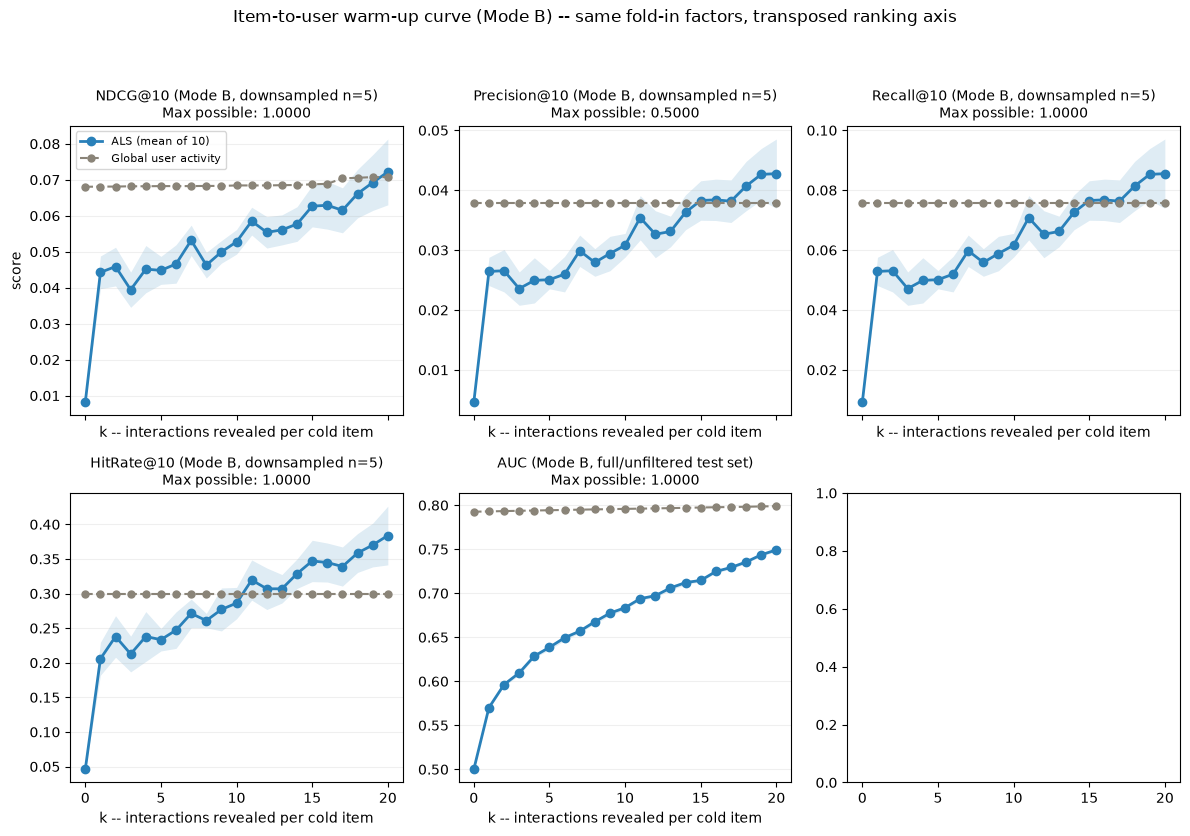

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8), sharex='col')
axes = axes.flatten()

for i, (ax, metric) in enumerate(zip(axes, METRICS_MODE_B)):
    als_mean = np.array(als_b_curve[metric]["mean"])
    als_std = np.array(als_b_curve[metric]["std"])
    show_label = (lambda text: text) if i == 0 else (lambda text: None)

    ax.plot(K_LEVELS, als_mean, marker="o", markersize=6, linewidth=2,
            color="#2980b9", label=show_label(f"ALS (mean of {N_SEEDS})"))
    ax.fill_between(K_LEVELS, als_mean - als_std, als_mean + als_std, color="#2980b9", alpha=0.15, linewidth=0)
    ax.plot(K_LEVELS, activity_b_curve[metric]["mean"], marker="o", markersize=5, linewidth=1.5,
            linestyle="--", color="#8A8478", label=show_label("Global user activity"))

    # Ceiling is noted in the title only, not drawn as a line -- an axhline at (often) 1.0 would
    # force the y-axis to stretch to include it, flattening out real differences between ALS
    # and Activity that only span a few hundredths (e.g. NDCG's ~0.07-0.11 range).

    title_line1 = ("AUC (Mode B, full/unfiltered test set)" if metric == "AUC"
                   else f"{metric}@{K_MODE_B} (Mode B, downsampled n={DOWNSAMPLE_SIZE})")
    ax.set_title(f"{title_line1}\nMax possible: {ceiling[metric]:.4f}", fontsize=10)
    ax.set_xlabel("k -- interactions revealed per cold item")
    ax.grid(axis="y", alpha=0.2)

axes[0].set_ylabel("score")
axes[0].legend(fontsize=8, loc="upper left")
fig.suptitle("Item-to-user warm-up curve (Mode B) -- same fold-in factors, transposed ranking axis", y=1.04)
plt.tight_layout()
plt.show()

### Reading the Downsampled Test Set results against AUC's full-set result

The four Downsampled Test Set metrics (NDCG, Precision, Recall, HitRate) and AUC tell
*different* stories here, and that's expected, not a contradiction — they're measured against
different populations on purpose.

On the Downsampled Test Set, **ALS crosses over and overtakes the global-user-activity floor**
on all four metrics somewhere between `k=11` and `k=15`, and the lead keeps growing through
`k=20`. Once every cold item is held to the same fixed difficulty (5 test users each), ALS's
actual per-item ranking signal shows through instead of being buried under the handful of
high-`r_i`, near-popular items that dominated the pooled average before.

AUC, still computed on the *full* reserved test set (every `r_i`, 5 to 487, included), keeps
showing ALS trailing Activity through `k=20`. That's not inconsistent with the downsampled
result — it isolates *where* the remaining gap lives: concentrated in the high-`r_i` items
specifically (where "target the generally active users" is close to unbeatable by
construction), not spread evenly across the cold-item population. On a fairness-controlled,
per-item basis, ALS's fold-in ranking is already adding real value by the middle of the reveal
sweep; on the full, blockbuster-inclusive population, it hasn't fully closed the gap by `k=20`.

## 11. Summary

- **Objective:** isolate the effect that a given retrieval method has on how quickly an item
  becomes recommendable as it accumulates interaction history — built so that future
  interventions (content embeddings, improved content embeddings, LLM-simulated interactions)
  can be slotted in and compared against this same baseline on equal footing.
- **The controlling principle:** user preferences are fit once (Section 5b, on `ref_train`)
  and reused identically everywhere in this notebook. Only the item's own representation
  changes as it accumulates revealed history.
- **Modularization:** the mechanism now lives in `load.py`/`pop.py`/`cf.py`/`eval.py` behind a
  shared `protocol.RetrievalModel` contract, so a future retrieval method plugs into the exact
  same `eval.sweep()`/`sweep_item_to_user()` calls used above — no new evaluation code required.